# Домашняя работа №5 — Регрессоры на Bike Sharing Dataset

**Датасет**: Bike Sharing Dataset (UCI). Будем предсказывать `cnt` — общее количество аренд (daily data).


## Установка библиотек

Устанавливаем необходимые библиотеки: catboost, lightgbm, xgboost и пр.

In [125]:
!pip install catboost lightgbm xgboost --quiet

## 1) Загрузка датасета (day.csv) и быстрая подготовка

In [126]:

import zipfile, io, requests, pandas as pd
# Скачиваем архив с UCI и читаем day.csv
zip_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip"
r = requests.get(zip_url)
z = zipfile.ZipFile(io.BytesIO(r.content))
with z.open('day.csv') as f:
    df = pd.read_csv(f)
print("Загружен day.csv, shape:", df.shape)
df.head()


Загружен day.csv, shape: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [127]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [128]:

# Статистическая информация
df.describe().style.background_gradient(cmap = "Blues")


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [129]:

# Информация о типах данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [130]:

# Нулевые значения
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [131]:
# Возвращает true для столбца, имеющего пустые значения, в противном случае false
df.isnull().any()

,0
instant,False
dteday,False
season,False
yr,False
mnth,False
holiday,False
weekday,False
workingday,False
weathersit,False
temp,False


In [132]:
# Уникальность
df.apply(lambda x : len(x.unique()))

,0
instant,731
dteday,731
season,4
yr,2
mnth,12
holiday,2
weekday,7
workingday,2
weathersit,3
temp,499


## Быстрая предобработка и выбор признаков
Удалим колонки instant, dteday и casual/registered, one-hot для категориальных.

In [133]:

data = df.copy()
drop_cols = ['instant','dteday','casual','registered']
for c in drop_cols:
    if c in data.columns:
        data.drop(columns=c, inplace=True)
# Обозначаем категориальные признаки (season, yr, mnth, holiday и т. д.) как категориальные.
cat_cols = ['season','yr','mnth','holiday','weekday','workingday','weathersit']
for c in cat_cols:
    data[c] = data[c].astype('category')
# Преобразуем категориальные переменные в числовые (one-hot encoding).
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)
# Целевая переменная y — это количество арендованных велосипедов (cnt).
y = data['cnt']
X = data.drop(columns=['cnt'])
print("X shape:", X.shape, "y shape:", y.shape)
X.head()


X shape: (731, 29) y shape: (731,)


,temp,atemp,hum,windspeed,season_2,season_3,season_4,yr_1,mnth_2,mnth_3,...,holiday_1,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3
0,0.344167,0.363625,0.805833,0.160446,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0.363478,0.353739,0.696087,0.248539,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0.196364,0.189405,0.437273,0.248309,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
3,0.200000,0.212122,0.590435,0.160296,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
4,0.226957,0.229270,0.436957,0.186900,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False


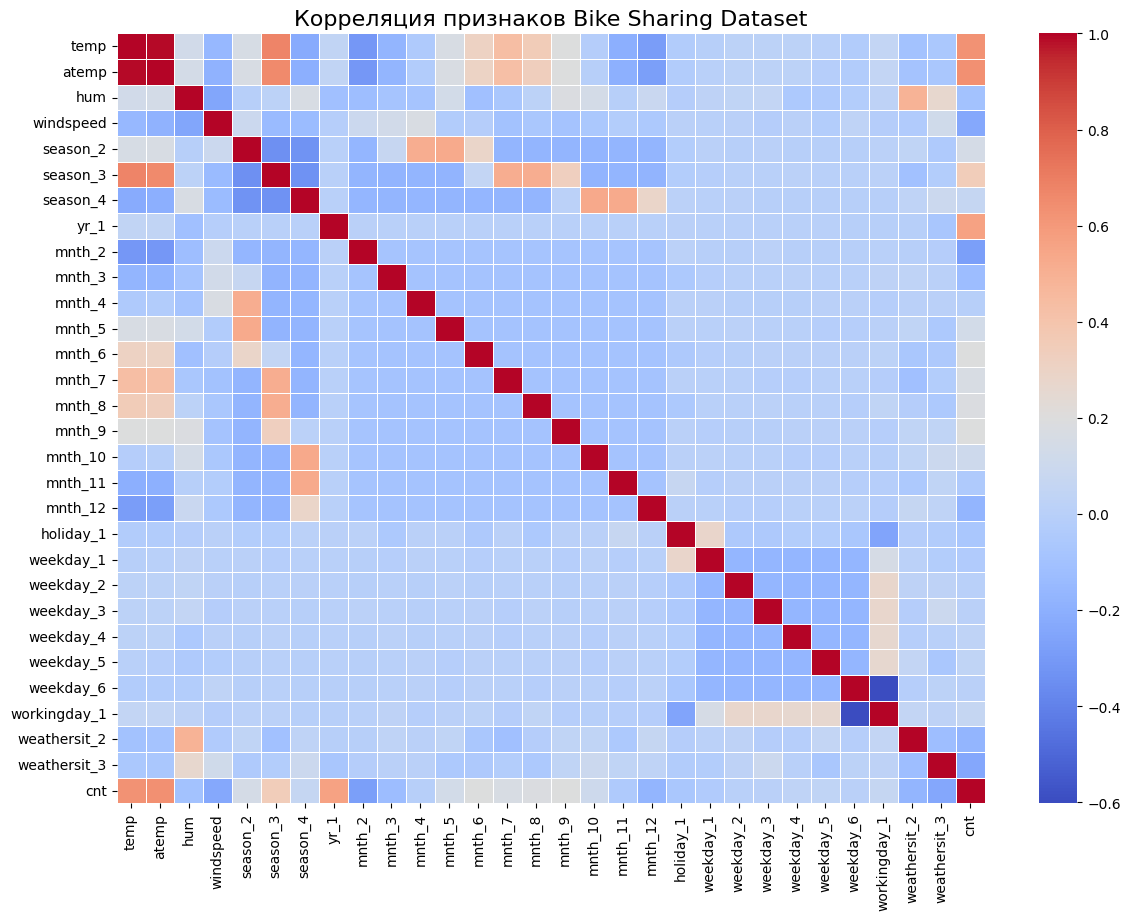

Топ-10 признаков по корреляции с cnt:
 cnt         1.000000
atemp       0.631066
temp        0.627494
yr_1        0.566710
season_3    0.346487
mnth_6      0.195866
mnth_9      0.194963
mnth_8      0.182426
mnth_7      0.166584
season_2    0.146197
mnth_5      0.132947
Name: cnt, dtype: float64


In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

# Объединим X и y обратно для анализа
data_corr = X.copy()
data_corr['cnt'] = y

# Корреляционная матрица
plt.figure(figsize=(14,10))
corr = data_corr.corr()

sns.heatmap(corr, cmap="coolwarm", annot=False, fmt=".2f", linewidths=0.5)
plt.title("Корреляция признаков Bike Sharing Dataset", fontsize=16)
plt.show()

# Посмотрим топ-10 признаков по корреляции с целевой переменной cnt
corr_target = corr['cnt'].sort_values(ascending=False)
print("Топ-10 признаков по корреляции с cnt:\n", corr_target.head(11))


### Вывод по корреляции:

cnt = 1.0 — это всегда так, с самим собой корреляция равна 1.

atemp (ощущаемая температура) = 0.63
→ Чем теплее погода ощущается, тем больше арендуют велосипеды.

temp (фактическая температура) = 0.63
→ Почти то же самое, логично: люди катаются чаще в хорошую погоду.

yr_1 (год = 2012) = 0.57
→ В 2012 году аренд стало явно больше, чем в 2011 → рост популярности.

season_3 (лето) = 0.35
→ Летом арендуют чаще, чем в другие сезоны.

mnth_6 (июнь) = 0.20
→ Пик сезона аренды.

mnth_9 (сентябрь) = 0.19
→ Всё ещё активный месяц.

mnth_8 (август) = 0.18
→ Тоже высокий сезон.

mnth_7 (июль) = 0.17
→ Лето в полном разгаре.

season_2 (весна) = 0.15
→ Весной аренды уже начинают расти.

## 2) Split и scaling

In [135]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Разделяем данные на обучающую (80%) и тестовую (20%) выборку.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Сохраняем немасштабированную копию X
X_train_check = X_train.copy()
X_test_check = X_test.copy()

# Выбираем числовые признаки
num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

# Масштабирование числовых признаков
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (584, 29) Test: (147, 29)


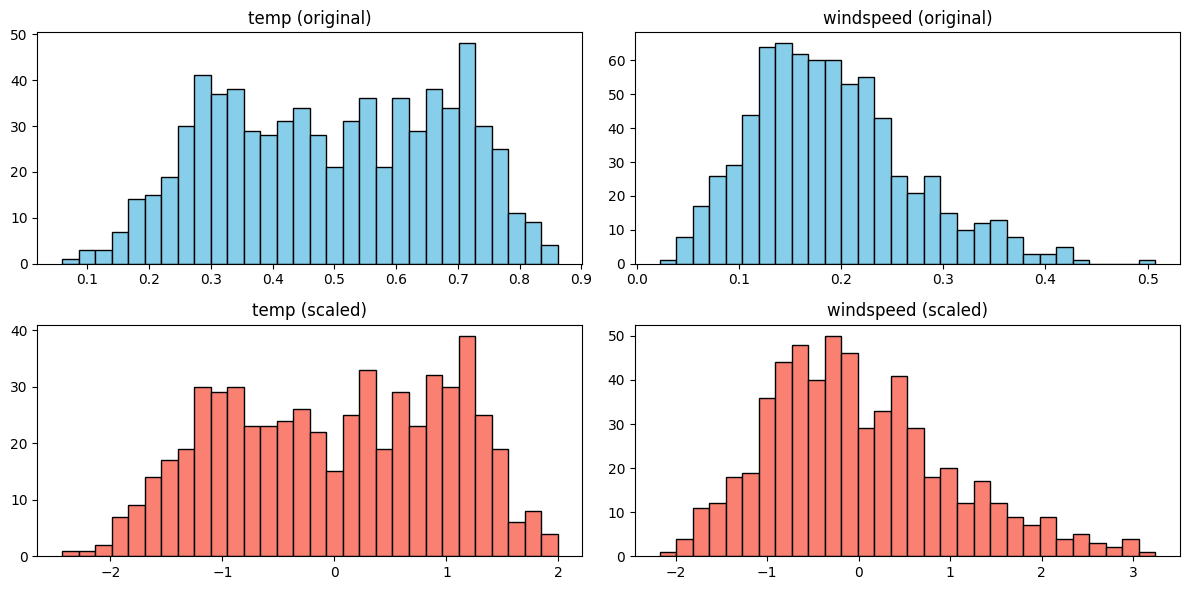

Сравнение статистик до и после масштабирования:


,Mean_before,Std_before,Mean_after,Std_after
temp,0.495385,0.183051,-2.372531e-16,1.000857
windspeed,0.190486,0.077498,2.250863e-16,1.000857


In [136]:
import matplotlib.pyplot as plt
import pandas as pd

# Выбираем несколько числовых признаков для анализа
cols_to_plot = ["temp", "windspeed"]

# === Визуализация распределений ===
fig, axes = plt.subplots(2, len(cols_to_plot), figsize=(12,6))

for i, col in enumerate(cols_to_plot):
    # До масштабирования
    axes[0, i].hist(X[col], bins=30, color="skyblue", edgecolor="black")
    axes[0, i].set_title(f"{col} (original)")

    # После масштабирования
    axes[1, i].hist(X_train[col], bins=30, color="salmon", edgecolor="black")
    axes[1, i].set_title(f"{col} (scaled)")

plt.tight_layout()
plt.show()

# === Численные значения ===
summary = pd.DataFrame({
    "Mean_before": X[cols_to_plot].mean(),
    "Std_before": X[cols_to_plot].std(),
    "Mean_after": X_train[cols_to_plot].mean(),
    "Std_after": X_train[cols_to_plot].std()
})

print("Сравнение статистик до и после масштабирования:")
display(summary)



## 3) Подмешивание синтетических признаков (опционально)

In [137]:


from sklearn.datasets import make_classification

X_syn, y_syn = make_classification(
    n_samples=X.shape[0],  # столько же строк, сколько в реальных данных
    n_features=5,          # 5 новых признаков
    n_informative=3,       # 3 из них информативные (имеют значение)
    random_state=1         # фиксируем случайность для повторяемости
)

# Создаём DataFrame
X_syn = pd.DataFrame(X_syn, columns=[f"syn_{i}" for i in range(X_syn.shape[1])])

# Берём оригинальные признаки (X) и добавляем к ним синтетические (X_syn).
X_aug = pd.concat([X.reset_index(drop=True), X_syn], axis=1)

from sklearn.model_selection import train_test_split

# Деление на train/test
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(X_aug, y, test_size=0.2, random_state=42)

num_cols_aug = X_train_aug.select_dtypes(include=['int64','float64']).columns.tolist()
scaler2 = StandardScaler()
X_train_aug[num_cols_aug] = scaler2.fit_transform(X_train_aug[num_cols_aug])
X_test_aug[num_cols_aug] = scaler2.transform(X_test_aug[num_cols_aug])
print('Aug shapes:', X_train_aug.shape, X_test_aug.shape)


Aug shapes: (584, 34) (147, 34)


До добавления синтетики: (731, 29)
После добавления синтетики: (731, 34)

Топ-10 признаков по корреляции с cnt:
 atemp           0.631066
temp            0.627494
yr_1            0.566710
season_3        0.346487
mnth_2          0.277764
weathersit_3    0.239958
windspeed       0.234545
mnth_6          0.195866
mnth_9          0.194963
mnth_8          0.182426
Name: cnt, dtype: float64

Корреляции синтетических признаков с cnt:
 syn_0    0.009790
syn_1   -0.006999
syn_2    0.031881
syn_3    0.026993
syn_4   -0.008266
Name: cnt, dtype: float64


/tmp/ipython-input-3739085301.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_syn.index, y=corr_syn.values, palette="coolwarm")


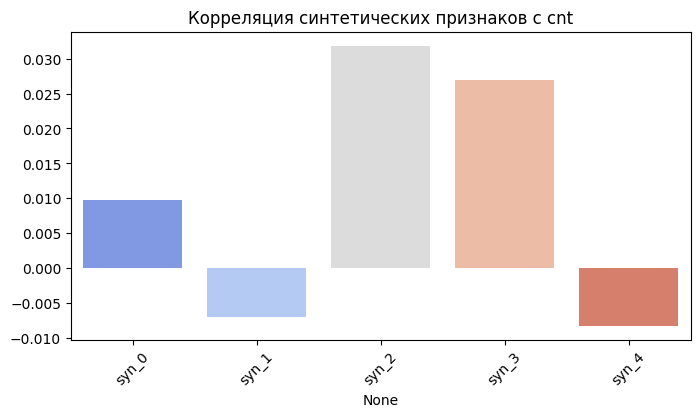

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Размер датасета
print("До добавления синтетики:", X.shape)
print("После добавления синтетики:", X_aug.shape)

# 2. Топ-10 признаков по корреляции
corr_all = pd.concat([X_aug, y.reset_index(drop=True)], axis=1).corr()['cnt'].drop('cnt')
print("\nТоп-10 признаков по корреляции с cnt:\n", corr_all.abs().sort_values(ascending=False).head(10))

# 3. Корреляция только синтетических признаков
corr_syn = pd.concat([X_syn, y.reset_index(drop=True)], axis=1).corr()['cnt'].drop('cnt')
print("\nКорреляции синтетических признаков с cnt:\n", corr_syn)

# 4. Визуализация синтетики
plt.figure(figsize=(8,4))
sns.barplot(x=corr_syn.index, y=corr_syn.values, palette="coolwarm")
plt.title("Корреляция синтетических признаков с cnt")
plt.xticks(rotation=45)
plt.show()



Вывод по добавлению make_classification → синтетика бесполезна (корреляция ≈ 0), значит модели будут работать так же, как и без неё. Добавленные признаки - ведут себя как шум, не несут полезной информации для предсказаний.

## 4) Модели (минимум 5). Будем обучать: RandomForest, ExtraTrees, GradientBoosting, XGBoost, LightGBM, CatBoost, KNN, Dummy

In [139]:

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42),
    'CatBoost': CatBoostRegressor(iterations=200, verbose=0, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'Dummy': DummyRegressor(strategy='mean')
}
len(models)


8

## 5) Функция для обучения/оценки (RMSE, MAE, R2)

In [144]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time, math
import pandas as pd

def evaluate_models(models, X_tr, X_te, y_tr, y_te):
    results = []
    for name, model in models.items():
        print(f"Training {name}...")
        t0 = time.time()
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        rmse = math.sqrt(mean_squared_error(y_te, y_pred))
        mae = mean_absolute_error(y_te, y_pred)
        r2 = r2_score(y_te, y_pred)
        elapsed = time.time() - t0
        results.append({'model':name,'rmse':rmse,'mae':mae,'r2':r2,'time_s':elapsed})
        print(f"{name}: RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}, time={elapsed:.1f}s\n")
    return pd.DataFrame(results).sort_values('rmse')

print('Evaluate on original features:')
res_orig = evaluate_models(models, X_train, X_test, y_train, y_test)
res_orig


Evaluate on original features:
Training RandomForest...
RandomForest: RMSE=721.897, MAE=468.115, R2=0.870, time=0.5s

Training ExtraTrees...
ExtraTrees: RMSE=790.399, MAE=493.892, R2=0.844, time=0.4s

Training GradientBoosting...
GradientBoosting: RMSE=680.027, MAE=488.642, R2=0.885, time=0.2s

Training XGBoost...
XGBoost: RMSE=670.776, MAE=464.328, R2=0.888, time=0.1s

Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000054 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 824
[LightGBM] [Info] Number of data points in the train set: 584, number of used features: 27
[LightGBM] [Info] Start training from score 4560.977740
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

,model,rmse,mae,r2,time_s
5,CatBoost,645.523239,429.109130,0.896082,0.344880
3,XGBoost,670.776066,464.328400,0.887792,0.141526
2,GradientBoosting,680.027160,488.641651,0.884676,0.230426
4,LightGBM,690.790426,457.435094,0.880996,0.053342
0,RandomForest,721.897022,468.115306,0.870037,0.504944
1,ExtraTrees,790.398558,493.891769,0.844202,0.364125
6,KNN,942.213100,733.389116,0.778606,0.008487
7,Dummy,2022.172809,1711.990926,-0.019776,0.002247


## 6) Обучение на расширённом наборе (с синтетикой)

In [141]:

print('Evaluate on augmented features:')
res_aug = evaluate_models(models, X_train_aug, X_test_aug, y_train_aug, y_test_aug)
res_aug


Evaluate on augmented features:
Training RandomForest...
RandomForest: RMSE=765.881, MAE=506.611, R2=0.854, time=1.7s

Training ExtraTrees...
ExtraTrees: RMSE=796.743, MAE=510.898, R2=0.842, time=1.7s

Training GradientBoosting...
GradientBoosting: RMSE=705.403, MAE=499.872, R2=0.876, time=1.4s

Training XGBoost...
XGBoost: RMSE=788.876, MAE=537.915, R2=0.845, time=1.1s

Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000234 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1799
[LightGBM] [Info] Number of data points in the train set: 584, number of used features: 32
[LightGBM] [Info] Start training from score 4560.977740
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

,model,rmse,mae,r2,time_s
5,CatBoost,669.458918,470.264952,0.888232,1.387694
2,GradientBoosting,705.403166,499.872055,0.875908,1.437282
4,LightGBM,724.807119,480.915853,0.868987,0.237399
0,RandomForest,765.881006,506.610680,0.853718,1.652262
3,XGBoost,788.875505,537.914734,0.844802,1.105547
1,ExtraTrees,796.743432,510.898231,0.841691,1.705569
6,KNN,1076.586900,873.025850,0.710954,0.019015
7,Dummy,2022.172809,1711.990926,-0.019776,0.003661


In [142]:
print(f"Orig\n {res_orig}...")
print(f"\nAug\n {res_aug}...")


Orig
               model         rmse          mae        r2    time_s
5          CatBoost   645.523239   429.109130  0.896082  0.637459
3           XGBoost   670.776066   464.328400  0.887792  0.852623
2  GradientBoosting   680.027160   488.641651  0.884676  0.444898
4          LightGBM   690.790426   457.435094  0.880996  0.103857
0      RandomForest   721.897022   468.115306  0.870037  1.140866
1        ExtraTrees   790.398558   493.891769  0.844202  0.733464
6               KNN   942.213100   733.389116  0.778606  0.012558
7             Dummy  2022.172809  1711.990926 -0.019776  0.002927...

Aug
               model         rmse          mae        r2    time_s
5          CatBoost   669.458918   470.264952  0.888232  1.387694
2  GradientBoosting   705.403166   499.872055  0.875908  1.437282
4          LightGBM   724.807119   480.915853  0.868987  0.237399
0      RandomForest   765.881006   506.610680  0.853718  1.652262
3           XGBoost   788.875505   537.914734  0.844802  1.10

## 7) Визуализация результатов — сравнение метрик и pred vs true для лучшей модели

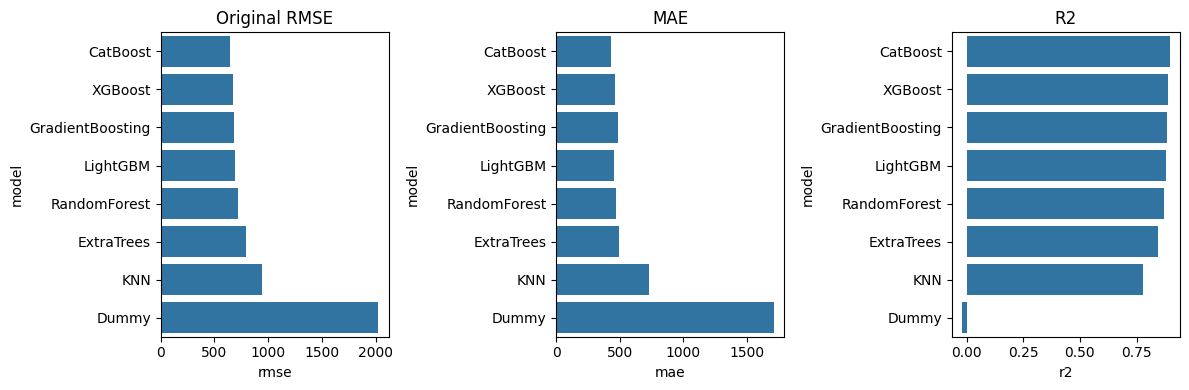

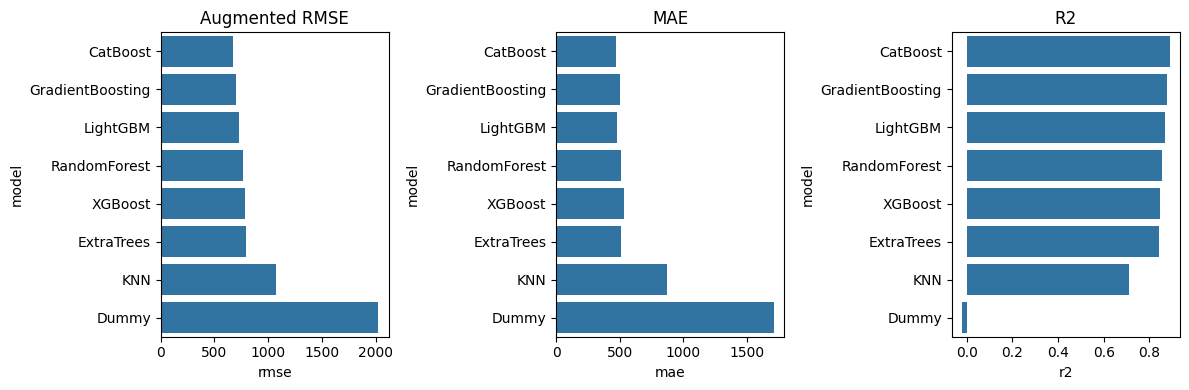

Лучшая модель: CatBoost


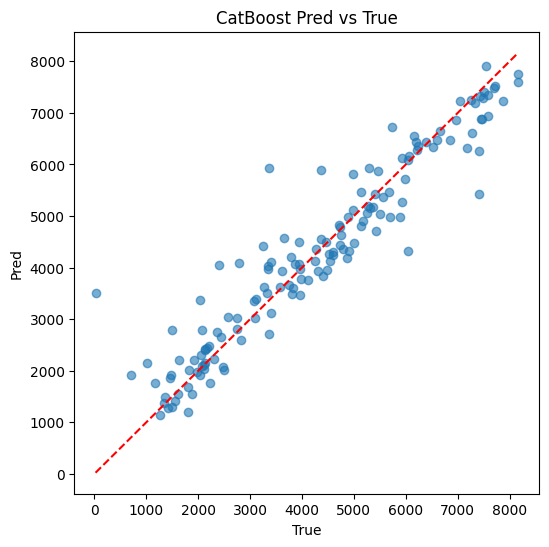

In [145]:

import numpy as np
import matplotlib.pyplot as plt, seaborn as sns
def plot_results(df_res, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); sns.barplot(data=df_res, x='rmse', y='model'); plt.title(title+' RMSE')
    plt.subplot(1,3,2); sns.barplot(data=df_res, x='mae', y='model'); plt.title('MAE')
    plt.subplot(1,3,3); sns.barplot(data=df_res, x='r2', y='model'); plt.title('R2')
    plt.tight_layout(); plt.show()

plot_results(res_orig, 'Original')
plot_results(res_aug, 'Augmented')

# Лучшая модель в оригинале
best_name = res_orig.sort_values('rmse').iloc[0]['model']
best_model = models[best_name]

print("Лучшая модель:", best_name)
print(best_model)

y_pred_best = best_model.predict(X_test)

# Визуализация предсказаний vs реальных значений
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  # линия идеального соответствия
plt.xlabel('True')
plt.ylabel('Pred')
plt.title(best_name + ' Pred vs True')
plt.show()
